# LC-MS Collection Processing
## Multi-Sample Metabolomics Workflow with Consensus Features

This notebook demonstrates how to process multiple LC-MS samples as a collection using CoreMS, enabling cross-sample comparison, alignment, and consensus feature detection.

### Workflow Overview
1. Prepare individual LC-MS samples and export to HDF5
2. Load samples as an LCMSCollection
3. Align retention times across samples
4. Generate consensus mass features (clustering)
5. Perform gap filling for missing features
6. Create pivot tables and cluster representatives
7. Add molecular annotations (MS1 formula search and MS2 spectral matching)
8. Export collection results
9. Visualize collection-level data

### Key Concepts
- **Consensus Features**: Clusters of mass features that represent the same chemical entity across samples
- **Gap Filling**: Searching raw data for features missing in a sample but present in others
- **Representative Features**: The best representative mass feature from each consensus cluster
- **Collection Pivot Table**: Matrix showing feature presence/absence or intensity across all samples

### Data Format
This tutorial uses the same Thermo Fisher RAW format LC-MS data as the LCMS_Tutorial, but processes it as a collection of 3 samples with different feature levels to demonstrate gap filling and collection-level analysis.

In [1]:
# Import required packages
import numpy as np
import pandas as pd
from pathlib import Path
import shutil

from corems.mass_spectra.input.rawFileReader import ImportMassSpectraThermoMSFileReader
from corems.mass_spectra.output.export import LCMSMetabolomicsExport, LCMSCollectionExport
from corems.mass_spectra.input.corems_hdf5 import ReadCoreMSHDFMassSpectraCollection
from corems.encapsulation.factory.parameters import LCMSParameters
from corems.molecular_id.search.database_interfaces import MSPInterface
from corems.encapsulation.factory.parameters import hush_output

# Running this keeps the notebook output cleaner and is recommended unless debugging
hush_output()

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## Step 1: Prepare Individual Samples

For this tutorial, we'll create 3 samples with different levels of mass features to demonstrate gap filling:
- **Sample 1**: Full set of mass features (reference sample)
- **Sample 2**: Partial set (first 50 features only)
- **Sample 3**: No mass features (extreme case for gap filling)

In a real workflow, you would process actual different samples, but this demonstrates the collection functionality.

In [2]:
# Set up paths for this tutorial
raw_file_path = Path('../../tests/tests_data/lcms/Blanch_Nat_Lip_C_12_AB_M_17_NEG_25Jan18_Brandi-WCSH5801.raw')
processed_folder = Path('./tutorial_collection_data')

# Clean up any existing tutorial data
if processed_folder.exists():
    shutil.rmtree(processed_folder)
processed_folder.mkdir()

print(f"Tutorial data will be saved to: {processed_folder.absolute()}")

Tutorial data will be saved to: /Users/heal742/LOCAL/corems_dev/corems/examples/notebooks/tutorial_collection_data


### Configure Processing Parameters

Set parameters appropriate for this dataset. These control peak picking, noise thresholding, and other processing steps.

In [3]:
# Load and configure the raw data
parser = ImportMassSpectraThermoMSFileReader(str(raw_file_path))
lcms_obj = parser.get_lcms_obj(spectra="ms1")

# Set parameters for fast processing
lcms_obj.parameters = LCMSParameters(use_defaults=True)

# Persistent homology peak picking parameters
lcms_obj.parameters.lc_ms.peak_picking_method = "persistent homology"
lcms_obj.parameters.lc_ms.ph_inten_min_rel = 0.001
lcms_obj.parameters.lc_ms.ph_persis_min_rel = 0.05
lcms_obj.parameters.lc_ms.ph_smooth_it = 0
lcms_obj.parameters.lc_ms.ms1_scans_to_average = 3

# MS1 parameters
ms1_params = lcms_obj.parameters.mass_spectrum['ms1']
ms1_params.mass_spectrum.noise_threshold_method = "relative_abundance"
ms1_params.mass_spectrum.noise_threshold_min_relative_abundance = 0.1
ms1_params.mass_spectrum.noise_min_mz = 0
ms1_params.mass_spectrum.min_picking_mz = 0
ms1_params.mass_spectrum.noise_max_mz = np.inf
ms1_params.mass_spectrum.max_picking_mz = np.inf
ms1_params = lcms_obj.parameters.mass_spectrum['ms1']

# Molecular formula search parameters
ms1_params.molecular_search.url_database = "" # This will run with a locally generated sqlite database
ms1_params.molecular_search.min_ppm_error = -5
ms1_params.molecular_search.max_ppm_error = 5
ms1_params.molecular_search.isRadical = False # Do not search for radical species, only protonated; the report will report the ion formula
ms1_params.molecular_search.usedAtoms = { # Elements and their min/max counts
    'C': (1, 90),
    'H': (4, 200),
    'O': (0, 30),
    'N': (0, 3),
    'P': (0, 2),
    'S': (0, 2),
}

# MS2 parameters
ms2_params = lcms_obj.parameters.mass_spectrum['ms2']
ms2_params.mass_spectrum.noise_threshold_method = "relative_abundance"
ms2_params.mass_spectrum.noise_threshold_min_relative_abundance = 1.0

print("Parameters configured for LC-MS processing")

Parameters configured for LC-MS processing


### Process and Create Sample 1 (Full Features)

In [4]:
# Find and integrate mass features, and find ms2 scans that are associated with these features
print("Finding mass features...")
lcms_obj.find_mass_features(assign_ms2_scans=True)
lcms_obj.integrate_mass_features(drop_if_fail=True)

num_features = len(lcms_obj.mass_features)
print(f"Found {num_features} mass features in Sample 1")

# Save all features for creating sample variations
all_mass_features = dict(lcms_obj.mass_features)
all_eics = dict(lcms_obj.eics)

# Export Sample 1 with all features
sample_name_1 = "test_sample_01"
exporter1 = LCMSMetabolomicsExport(str(processed_folder / sample_name_1), lcms_obj)
exporter1.to_hdf(overwrite=True)
print(f"✓ Exported Sample 1: {num_features} features")

Finding mass features...
Found 129 initial mass features
Found 126 mass features in Sample 1
✓ Exported Sample 1: 126 features


### Create Sample 2 (Partial Features)

Take only the first 50 mass features to simulate a sample with fewer detected features.

In [5]:
# Create Sample 2 with partial features
sample_name_2 = "test_sample_02"
first_50_mf_ids = list(lcms_obj.mass_features.keys())[:50]
lcms_obj.mass_features = {mf_id: all_mass_features[mf_id] for mf_id in first_50_mf_ids}

exporter2 = LCMSMetabolomicsExport(str(processed_folder / sample_name_2), lcms_obj)
exporter2.to_hdf(overwrite=True)
print(f"✓ Exported Sample 2: 50 features")

✓ Exported Sample 2: 50 features


### Create Sample 3 (No Features)

Clear all features to simulate an extreme case where gap filling will be needed for all features.

In [6]:
# Create Sample 3 with no features
sample_name_3 = "test_sample_03"
lcms_obj.mass_features = {}
lcms_obj.eics = {}

exporter3 = LCMSMetabolomicsExport(str(processed_folder / sample_name_3), lcms_obj)
exporter3.to_hdf(overwrite=True)
print(f"✓ Exported Sample 3: 0 features (will be gap-filled)")

✓ Exported Sample 3: 0 features (will be gap-filled)


### Create Collection Manifest

A manifest file defines the sample metadata including batch, order, and which sample is the center (reference) for alignment.

In [7]:
# Create manifest file
import csv
manifest_path = processed_folder / "manifest.csv"
with open(manifest_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['sample_name', 'batch', 'order', 'center'])
    writer.writerow(['test_sample_01', 1, 1, True])   # Sample 1 is center (reference)
    writer.writerow(['test_sample_02', 1, 2, False])
    writer.writerow(['test_sample_03', 1, 3, False])

print(f"✓ Created manifest with 3 samples")
print("\nSample preparation complete!")

✓ Created manifest with 3 samples

Sample preparation complete!


## Step 2: Load the Collection

Load all samples as a collection. The manifest defines which samples to include and their metadata. If not manifest is provided, samples can be loaded directly and a manifest will be generated automatically using the collection times to deduce batch/order, which is important for alignment. For our case, we will use the manifest we created since we have specific batch/order information.

In [8]:
# Load collection from processed samples
parser = ReadCoreMSHDFMassSpectraCollection(
    folder_location=processed_folder,
    manifest_file=manifest_path,
    cores=1
)

# Load collection (light loading for efficiency - doesn't load all raw MS data)
lcms_collection = parser.get_lcms_collection()

print(f"Loaded collection with {len(lcms_collection)} samples")
print(f"Total mass features across all samples: {len(lcms_collection.mass_features_dataframe)}")

Loaded collection with 3 samples
Total mass features across all samples: 176


### Examine Collection Structure

In [9]:
# View sample names
print("Samples in collection:")
for i, sample_name in enumerate(lcms_collection.samples):
    num_features = len(lcms_collection[i].mass_features)
    print(f"  {i}: {sample_name} - {num_features} features")

# View manifest dataframe
print("\nManifest:")
display(lcms_collection.manifest_dataframe)

Samples in collection:
  0: test_sample_01 - 0 features
  1: test_sample_02 - 0 features
  2: test_sample_03 - 0 features

Manifest:


,batch,order,center,collection_id
test_sample_01,1,1,True,0
test_sample_02,1,2,False,1
test_sample_03,1,3,False,2


In [10]:
# View mass features dataframe (first few rows)
print("\nMass Features Dataframe (all features from all samples):")
display(lcms_collection.mass_features_dataframe.head(10))


Mass Features Dataframe (all features from all samples):


,sample_name,sample_id,mf_id,mz,type,scan_time,apex_scan,start_scan,final_scan,intensity,...,dispersity_index,normalized_dispersity_index,noise_score,noise_score_min,noise_score_max,monoisotopic_mf_id,isotopologue_type,mass_spectrum_deconvoluted_parent,ms2_scan_numbers,_eic_mz
coll_mf_id,,,,,,,,,,,,,,,,,,,,,
0_0,test_sample_01,0,0.0,301.216614,untargeted,8.895637,1882.0,1828.0,2008.0,66775328.00,...,NaN,NaN,NaN,NaN,NaN,None,None,None,"[1874, 1910]",301.216614
0_1,test_sample_01,0,1.0,367.357483,untargeted,19.152648,4069.0,4024.0,4312.0,48137056.00,...,NaN,NaN,NaN,NaN,NaN,None,None,None,"[4036, 4037, 4070]",367.357483
0_10,test_sample_01,0,10.0,698.628906,untargeted,23.816803,5212.0,5176.0,5338.0,17265106.00,...,NaN,NaN,NaN,NaN,NaN,None,None,None,"[5195, 5196, 5231, 5232]",698.628906
0_100,test_sample_01,0,100.0,569.196899,untargeted,4.421147,775.0,721.0,856.0,4048302.00,...,NaN,NaN,NaN,NaN,NaN,None,None,None,"[749, 750, 785, 786]",569.196899
0_101,test_sample_01,0,101.0,300.204865,untargeted,7.376470,1513.0,1477.0,1585.0,4030582.25,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],300.204865
0_102,test_sample_01,0,102.0,456.356628,untargeted,8.965470,1900.0,1855.0,1999.0,4012202.00,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],456.356628
0_103,test_sample_01,0,103.0,527.467590,untargeted,17.558470,3718.0,3682.0,3826.0,4000847.75,...,NaN,NaN,NaN,NaN,NaN,None,None,None,"[3703, 3704, 3737, 3738]",527.467590
0_104,test_sample_01,0,104.0,736.510437,untargeted,20.793637,4483.0,4438.0,4609.0,3974837.75,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],736.510437
0_105,test_sample_01,0,105.0,256.235962,untargeted,9.071805,1927.0,1891.0,2062.0,3900504.25,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],256.235962


### Configure Collection Parameters

Set parameters for alignment, clustering, and gap filling.

In [11]:
# Alignment parameters
lcms_collection.parameters.lcms_collection.mass_feature_anchor_technique = ['relative_intensity']
lcms_collection.parameters.lcms_collection.mass_feature_anchor_relative_intensity_threshold = 0.0
lcms_collection.parameters.lcms_collection.alignment_mz_tol_ppm = 5
lcms_collection.parameters.lcms_collection.alignment_rt_tol = 0.2  # 12 seconds

print("Collection parameters configured")

Collection parameters configured


## Step 3: Align Retention Times

Align retention times across samples to account for chromatographic drift.

In [12]:
# Perform RT alignment
print(f"RT aligned before alignment: {lcms_collection.rt_aligned}")

lcms_collection.align_lcms_objects()

print(f"RT alignment attempted: {lcms_collection.rt_alignment_attempted}")
print(f"RT aligned after alignment: {lcms_collection.rt_aligned}")

# Check that scan_time_aligned was added to all samples
for i, lcms_obj in enumerate(lcms_collection):
    has_aligned = 'scan_time_aligned' in lcms_obj.scan_df.columns
    print(f"  Sample {i} has scan_time_aligned: {has_aligned}")

RT aligned before alignment: False
RT alignment attempted: True
RT aligned after alignment: False
  Sample 0 has scan_time_aligned: True
  Sample 1 has scan_time_aligned: True
  Sample 2 has scan_time_aligned: True


### Visualize TICs and Alignment

In our case, the samples will not use any alignment since they are exact replicas. Therefore the aligned plot (lower) will be overlapping.  Even if samples do not need alignment, running `align_lcms_objects()` is important as it will trigger the collection-level flag that alignment was attempted, which is a prerequisit for finding consensus mass features

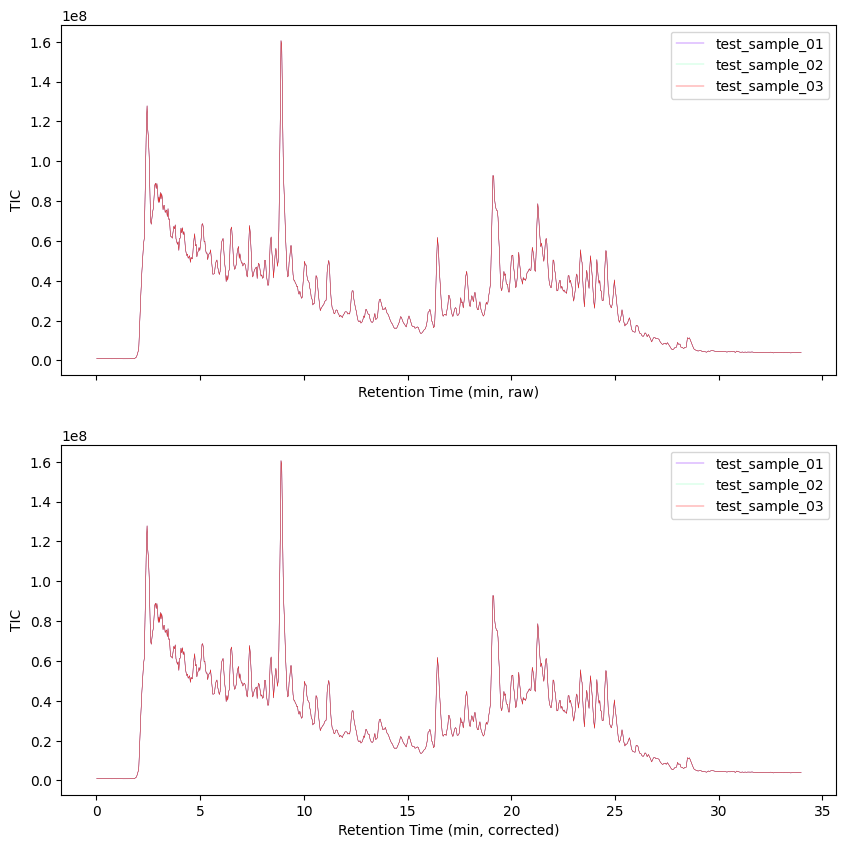

In [13]:
# Plot TICs (Total Ion Chromatograms) before and after alignment
# Enable inline plotting for Jupyter notebooks
%matplotlib inline

lcms_collection.plot_tics(ms_level=1, type="both", plot_legend=True)

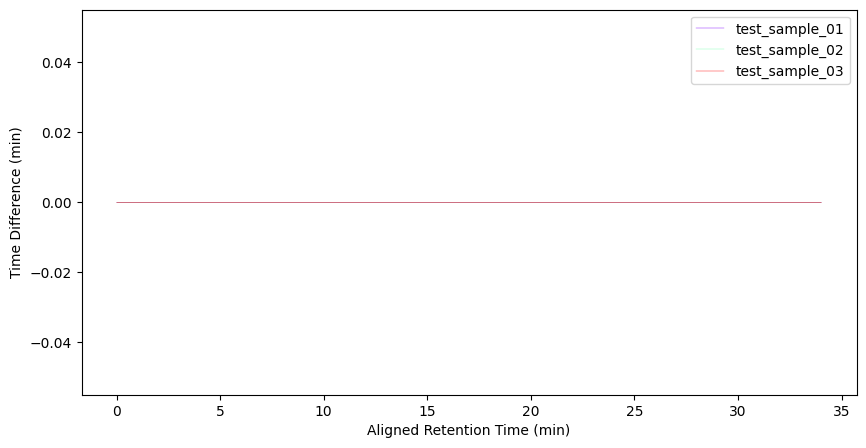

Generated alignment plot showing RT differences (no differences for our exampl, which is expected)


In [14]:
# Plot alignment differences (no differences for this example, no alignment was used)
lcms_collection.plot_alignments(plot_legend=True)
print("Generated alignment plot showing RT differences (no differences for our exampl, which is expected)")

## Step 4: Generate Consensus Mass Features (Clustering)

Cluster mass features across samples to identify consensus features - features representing the same chemical entity across multiple samples.

In [15]:
# Generate consensus features
lcms_collection.add_consensus_mass_features()

cluster_summary = lcms_collection.cluster_summary_dataframe
print(f"Generated {len(cluster_summary)} consensus clusters")

# View cluster summary
print("\nCluster Summary (first 10 clusters):")
display(cluster_summary.head(10))

Generated 50 consensus clusters

Cluster Summary (first 10 clusters):


,mz_median,mz_mean,mz_std,mz_max,mz_min,scan_time_aligned_median,scan_time_aligned_mean,scan_time_aligned_std,scan_time_aligned_max,scan_time_aligned_min,...,dispersity_index_median,dispersity_index_mean,dispersity_index_std,dispersity_index_max,dispersity_index_min,persistence_max,persistence_median,persistence_mean,persistence_std,persistence_min
cluster,,,,,,,,,,,,,,,,,,,,,
0,301.216614,301.216614,0.0,301.216614,301.216614,8.895637,8.895637,0.0,8.895637,8.895637,...,NaN,NaN,NaN,NaN,NaN,66708546.0,66708546.0,66708546.0,0.0,66708546.0
1,302.220612,302.220612,0.0,302.220612,302.220612,8.895637,8.895637,0.0,8.895637,8.895637,...,NaN,NaN,NaN,NaN,NaN,14142901.0,14142901.0,14142901.0,0.0,14142901.0
2,367.357483,367.357483,0.0,367.357483,367.357483,19.152648,19.152648,0.0,19.152648,19.152648,...,NaN,NaN,NaN,NaN,NaN,48070260.0,48070260.0,48070260.0,0.0,48070260.0
3,368.361176,368.361176,0.0,368.361176,368.361176,19.152648,19.152648,0.0,19.152648,19.152648,...,NaN,NaN,NaN,NaN,NaN,12650608.0,12650608.0,12650608.0,0.0,12650608.0
4,698.628906,698.628906,0.0,698.628906,698.628906,23.816803,23.816803,0.0,23.816803,23.816803,...,NaN,NaN,NaN,NaN,NaN,17198326.0,17198326.0,17198326.0,0.0,17198326.0
6,699.631226,699.631226,0.0,699.631226,699.631226,23.816803,23.816803,0.0,23.816803,23.816803,...,NaN,NaN,NaN,NaN,NaN,7795191.0,7795191.0,7795191.0,0.0,7795191.0
9,227.201889,227.201889,0.0,227.201889,227.201889,7.376470,7.376470,0.0,7.376470,7.376470,...,NaN,NaN,NaN,NaN,NaN,9533297.0,9533297.0,9533297.0,0.0,9533297.0
10,299.201111,299.201111,0.0,299.201111,299.201111,7.376470,7.376470,0.0,7.376470,7.376470,...,NaN,NaN,NaN,NaN,NaN,18192197.0,18192197.0,18192197.0,0.0,18192197.0
12,455.352661,455.352661,0.0,455.352661,455.352661,8.965470,8.965470,0.0,8.965470,8.965470,...,NaN,NaN,NaN,NaN,NaN,12872638.0,12872638.0,12872638.0,0.0,12872638.0


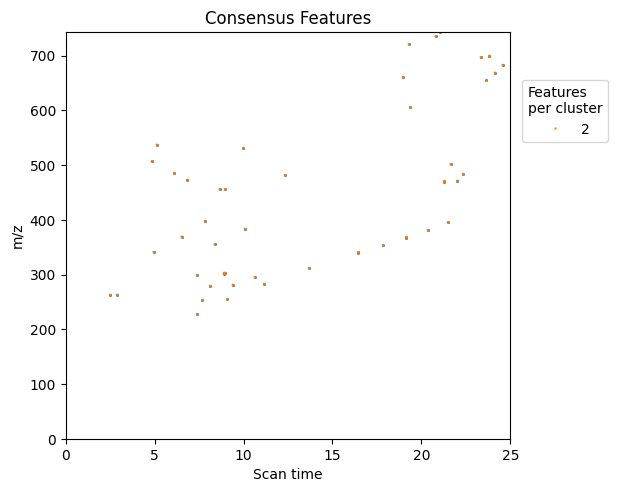

In [16]:
# View an overview plot of the consensus features
lcms_collection.plot_consensus_mz_features()

In [17]:
# View cluster feature dictionary (which features belong to which cluster)
cluster_dict = lcms_collection.cluster_feature_dictionary
print(f"\nTotal clusters in dictionary: {len(cluster_dict)}")
print("\nExample - Cluster 0 contains these features:")
if 0 in cluster_dict:
    for feature in cluster_dict[0][:5]:  # Show first 5
        print(f"  {feature}")
print("The features are tagged as sampleid_massfeatureid.")
print("So for this example, the first cluster contains the first mass feature (_0) from the first (0_) and second (1_) samples")


Total clusters in dictionary: 50

Example - Cluster 0 contains these features:
  0_0
  1_0
The features are tagged as sampleid_massfeatureid.
So for this example, the first cluster contains the first mass feature (_0) from the first (0_) and second (1_) samples


## Step 5: Process consensus mass features

Now that we have the consensus mass features, we can process them.  To do that we'll use the `process_consensus_features` step. In this step you'll trigger certain actions on each of the samples within your collection.

For this example, we will perform gap filling.  Later on we'll perform the annotations with molecular formula searching and MS2 spectra matching, though you can trigger all these steps at once.  If your parameters on your collection are set for multi-core (by setting the `lcms_collection.parameters.lcms_collection.cores` parameter), this would perform these actions using multicore processing on a sample-by-sample basis.  

In [18]:
# Perform gap filling
print("Performing gap filling...")
pipeline_results = lcms_collection.process_consensus_features(
    load_representatives=False,
    perform_gap_filling=True,
    add_ms1=False,
    add_ms2=False,
    molecular_formula_search=False,
    ms2_spectral_search=False,
    spectral_lib=False,
    molecular_metadata=None,
    gather_eics=False,
    keep_raw_data=False
)

# Check induced (gap-filled) features
induced_df = lcms_collection.induced_mass_features_dataframe
print(f"\nTotal induced features: {len(induced_df)}")

# Check per sample
for sample_id in range(len(lcms_collection)):
    sample_induced = len(induced_df[induced_df['sample_id'] == sample_id])
    print(f"  Sample {sample_id}: {sample_induced} gap-filled features")

Performing gap filling...

Gap-filling:


100%|█████████████████████████████████████████| 3/3 [00:21<00:00,  7.07s/sample]


Total induced features: 50
  Sample 0: 0 gap-filled features
  Sample 1: 0 gap-filled features
  Sample 2: 50 gap-filled features


In [19]:
# View induced features dataframe
print("\nInduced Features (first 10):")
display(induced_df.head(10))


Induced Features (first 10):


,sample_name,sample_id,mf_id,mz,scan_time_aligned,cluster,type,scan_time,apex_scan,start_scan,...,dispersity_index,normalized_dispersity_index,noise_score,noise_score_min,noise_score_max,monoisotopic_mf_id,isotopologue_type,mass_spectrum_deconvoluted_parent,ms2_scan_numbers,_eic_mz
coll_mf_id,,,,,,,,,,,,,,,,,,,,,
2_c0_0_i,test_sample_03,2,c0_0_i,301.216846,8.895637,0,untargeted,8.895637,1882.0,1828,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],301.216614
2_c1_1_i,test_sample_03,2,c1_1_i,302.220227,8.895637,1,untargeted,8.895637,1882.0,1828,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],302.220612
2_c2_2_i,test_sample_03,2,c2_2_i,367.357490,19.152648,2,untargeted,19.152648,4069.0,4024,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],367.357483
2_c3_3_i,test_sample_03,2,c3_3_i,368.360908,19.152648,3,untargeted,19.152648,4069.0,4024,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],368.361176
2_c4_4_i,test_sample_03,2,c4_4_i,698.629511,23.816803,4,untargeted,23.816803,5212.0,5176,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],698.628906
2_c6_5_i,test_sample_03,2,c6_5_i,699.632755,23.816803,6,untargeted,23.816803,5212.0,5176,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],699.631226
2_c9_6_i,test_sample_03,2,c9_6_i,227.201872,7.376470,9,untargeted,7.376470,1513.0,1477,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],227.201889
2_c10_7_i,test_sample_03,2,c10_7_i,299.201494,7.376470,10,untargeted,7.376470,1513.0,1477,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],299.201111
2_c12_8_i,test_sample_03,2,c12_8_i,455.352431,8.965470,12,untargeted,8.965470,1900.0,1855,...,NaN,NaN,NaN,NaN,NaN,None,None,None,[],455.352661


## Step 6: Create Pivot Tables

Pivot tables provide a matrix view of features across samples, useful for comparing intensities and detecting missing values.

In [20]:
# Create pivot table BEFORE gap filling (to compare)
# First, reload collection without gap filling to see the difference
parser2 = ReadCoreMSHDFMassSpectraCollection(
    folder_location=processed_folder,
    manifest_file=manifest_path,
    cores=1
)
collection_before = parser2.get_lcms_collection(load_raw=False, load_light=False)
collection_before.parameters.lcms_collection.cluster_size_min_samples = 1
collection_before.align_lcms_objects()
collection_before.add_consensus_mass_features()

pivot_before = collection_before.collection_pivot_table(verbose=False)
print("Pivot table BEFORE gap filling:")
print(f"Shape: {pivot_before.shape}")
print(f"\nSample 3 NAs: {pivot_before['test_sample_03'].isna().sum()} / {len(pivot_before)}")
display(pivot_before.head(10))

Pivot table BEFORE gap filling:
Shape: (50, 3)

Sample 3 NAs: 50 / 50


sample_name,test_sample_01,test_sample_02,test_sample_03
cluster,,,
0,0_0,1_0,NaN
1,0_19,1_19,NaN
2,0_1,1_1,NaN
3,0_24,1_24,NaN
4,0_10,1_10,NaN
6,0_42,1_42,NaN
9,0_28,1_28,NaN
10,0_9,1_9,NaN
12,0_21,1_21,NaN


In [21]:
# Create pivot table AFTER gap filling
pivot_after = lcms_collection.collection_pivot_table(verbose=False)
print("\nPivot table AFTER gap filling:")
print(f"Shape: {pivot_after.shape}")
print(f"\nSample 3 NAs: {pivot_after['test_sample_03'].isna().sum()} / {len(pivot_after)}")
display(pivot_after.head(10))

# Show the difference
print(f"\nGap filling filled {pivot_before['test_sample_03'].isna().sum() - pivot_after['test_sample_03'].isna().sum()} features in Sample 3")


Pivot table AFTER gap filling:
Shape: (50, 3)

Sample 3 NAs: 0 / 50


sample_name,test_sample_01,test_sample_02,test_sample_03
cluster,,,
0,0_0,1_0,2_c0_0_i
1,0_19,1_19,2_c1_1_i
2,0_1,1_1,2_c2_2_i
3,0_24,1_24,2_c3_3_i
4,0_10,1_10,2_c4_4_i
6,0_42,1_42,2_c6_5_i
9,0_28,1_28,2_c9_6_i
10,0_9,1_9,2_c10_7_i
12,0_21,1_21,2_c12_8_i



Gap filling filled 50 features in Sample 3


In [22]:
# Create pivot table with intensity values
pivot_intensity = lcms_collection.collection_pivot_table(attribute='intensity', verbose=False)
print("\nPivot table with intensities:")
display(pivot_intensity.head(10))


Pivot table with intensities:


sample_name,test_sample_01,test_sample_02,test_sample_03
cluster,,,
0,66775328.0,66775328.0,66775328.0
1,14249711.0,14249711.0,14249711.0
2,48137056.0,48137056.0,48137056.0
3,12717404.0,12717404.0,12717404.0
4,17265106.0,17265106.0,17265106.0
6,7861987.5,7861987.5,7861987.5
9,9600092.0,9600092.0,9600092.0
10,18258992.0,18258992.0,18258992.0
12,12939420.0,12939420.0,12939420.0


## Step 7: Cluster Representatives

Get the best representative mass feature for each consensus cluster.

In [23]:
# Get cluster representatives
reps_table = lcms_collection.cluster_representatives_table()
print(f"Cluster representatives: {len(reps_table)} clusters")
display(reps_table.head(10))

# Verify each cluster has exactly one representative
cluster_counts = reps_table['cluster'].value_counts()
print(f"\nAll clusters have 1 representative: {all(count == 1 for count in cluster_counts)}")

Cluster representatives: 50 clusters


,cluster,coll_mf_id,sample_name,sample_id,mf_id,mz,type,scan_time,apex_scan,start_scan,...,monoisotopic_mf_id,isotopologue_type,mass_spectrum_deconvoluted_parent,ms2_scan_numbers,_eic_mz,scan_time_aligned,partition_idx,idx,polarity,n_samples_detected
0,0,0_0,test_sample_01,0,0.0,301.216614,untargeted,8.895637,1882.0,1828.0,...,None,None,None,"[1874, 1910]",301.216614,8.895637,0.0,0.0,negative,3
2,1,0_19,test_sample_01,0,19.0,302.220612,untargeted,8.895637,1882.0,1828.0,...,None,None,None,[],302.220612,8.895637,0.0,2.0,negative,3
4,2,0_1,test_sample_01,0,1.0,367.357483,untargeted,19.152648,4069.0,4024.0,...,None,None,None,"[4036, 4037, 4070]",367.357483,19.152648,0.0,4.0,negative,3
6,3,0_24,test_sample_01,0,24.0,368.361176,untargeted,19.152648,4069.0,4024.0,...,None,None,None,[],368.361176,19.152648,0.0,6.0,negative,3
8,4,0_10,test_sample_01,0,10.0,698.628906,untargeted,23.816803,5212.0,5176.0,...,None,None,None,"[5195, 5196, 5231, 5232]",698.628906,23.816803,0.0,8.0,negative,3
10,6,0_42,test_sample_01,0,42.0,699.631226,untargeted,23.816803,5212.0,5176.0,...,None,None,None,[],699.631226,23.816803,0.0,11.0,negative,3
12,9,0_28,test_sample_01,0,28.0,227.201889,untargeted,7.376470,1513.0,1477.0,...,None,None,None,"[1496, 1532]",227.201889,7.376470,0.0,15.0,negative,3
14,10,0_9,test_sample_01,0,9.0,299.201111,untargeted,7.376470,1513.0,1477.0,...,None,None,None,"[1493, 1494, 1523]",299.201111,7.376470,0.0,17.0,negative,3
16,12,0_21,test_sample_01,0,21.0,455.352661,untargeted,8.965470,1900.0,1855.0,...,None,None,None,"[1865, 1866, 1912, 1913]",455.352661,8.965470,0.0,20.0,negative,3
18,15,0_35,test_sample_01,0,35.0,735.507019,untargeted,20.793637,4483.0,4438.0,...,None,None,None,"[4461, 4462, 4493, 4494]",735.507019,20.793637,0.0,24.0,negative,3



All clusters have 1 representative: True


## Step 8: Feature Annotations

Next we will annotate the features in MS1 (molecular formula searching) and MS2 (comparison to an MS2 spectral database).


In [24]:
# First we need to prepare a search space for the MS2 spectral search using a small testing MSP file
msp_file = Path('../../tests/tests_data/lcms/test_db.msp')
my_msp = MSPInterface(file_path=str(msp_file))
spectral_library, molecular_metadata = my_msp.get_metabolomics_spectra_library(
    polarity="negative",
    format="flashentropy",
    normalize=True,
    fe_kwargs={
        "normalize_intensity": True,
        "min_ms2_difference_in_da": 0.02,
        "max_ms2_tolerance_in_da": 0.01,
        "max_indexed_mz": 3000,
        "precursor_ions_removal_da": None,
        "noise_threshold": 0,
    },
)

# Set MS2 score threshold for each sample to enable finding spectral matches
# This threshold determines the minimum similarity score required for a match
for lcms_obj in lcms_collection:
    lcms_obj.parameters.lc_ms.ms2_min_fe_score = 0.3
    
pipeline_results = lcms_collection.process_consensus_features(
    load_representatives=True, # Load representative features for processing
    perform_gap_filling=False, # No gap filling this time, already done
    add_ms1=True, # Need to add and process MS1 data for molecular formula searching, but only for representative features
    add_ms2=True, # Need to add and process MS2 data for spectral searching, but only for representative features
    molecular_formula_search=False, # Perform molecular formula searching
    ms2_spectral_search=True, # Perform MS2 spectral searching
    spectral_lib=spectral_library, # Provide the spectral library we created above
    molecular_metadata=molecular_metadata, # Provide molecular metadata for annotations
    gather_eics=True # Gather EICs to plot later on
)
print("✓ Molecular formula search complete")


Reloading features, ms2 spectral search, loading eics:


100%|█████████████████████████████████████████| 3/3 [00:12<00:00,  4.12s/sample]



Associating EICs with mass features:


100%|███████████████████████████████████████| 3/3 [00:00<00:00, 1808.15sample/s]

✓ Molecular formula search complete


### View Feature Annotations Table

The feature annotations table combines cluster information with molecular annotations from both MS1 and MS2 searches.

In [25]:
# Get annotations table (from collection with formula search if available)
annotations_table = lcms_collection.feature_annotations_table(
    molecular_metadata=molecular_metadata,  # Pass molecular_metadata to include MS2 spectral match info
    drop_unannotated=True # Only show features with annotations
)
print(f"Annotations table: {len(annotations_table)} rows")
display(annotations_table.head())

Annotations table: 7 rows


,cluster,Isotopologue Type,Is Largest Ion after Deconvolution,MS2 Spectrum,Calculated m/z,m/z Error (ppm),m/z Error Score,Isotopologue Similarity,Confidence Score,Ion Formula,Ion Type,Molecular Formula,inchikey,name,ref_ms_id,Entropy Similarity,Library mzs in Query (fraction),Spectra with Annotation (n),representative_sample
1,2,None,None,367.3582:1.0,NaN,NaN,NaN,NaN,NaN,C24 H47 O2,[M-H]-,C24H48O2,QZZGJDVWLFXDLK-UHFFFAOYSA-N,Lignoceric Acid,CCMSLIB00004684071,0.783400,0.500000,2.0,test_sample_01
22,12,None,None,455.3532:1.0; 456.3585:0.01,NaN,NaN,NaN,NaN,NaN,C30 H47 O3,[M-H]-,C30H48O3,WCGUUGGRBIKTOS-UHFFFAOYSA-N,"Urs-12-en-28-oic acid, 3-hydroxy-, (3beta)-",CCMSLIB00010125334,0.576854,0.142857,2.0,test_sample_01
23,12,None,None,455.3532:1.0; 456.3585:0.01,NaN,NaN,NaN,NaN,NaN,C30 H47 O3,[M-H]-,C30H48O3,MIJYXULNPSFWEK-UHFFFAOYSA-N,3-Hydroxyolean-12-en-28-oic acid,CCMSLIB00010113749,0.542970,0.111111,2.0,test_sample_01
15,55,None,None,455.3531:1.0,NaN,NaN,NaN,NaN,NaN,C30 H47 O3,[M-H]-,C30H48O3,WCGUUGGRBIKTOS-UHFFFAOYSA-N,"Urs-12-en-28-oic acid, 3-hydroxy-, (3beta)-",CCMSLIB00010125334,0.645873,0.142857,2.0,test_sample_01
16,55,None,None,455.3531:1.0,NaN,NaN,NaN,NaN,NaN,C30 H47 O3,[M-H]-,C30H48O3,MIJYXULNPSFWEK-UHFFFAOYSA-N,3-Hydroxyolean-12-en-28-oic acid,CCMSLIB00010113749,0.606140,0.111111,2.0,test_sample_01


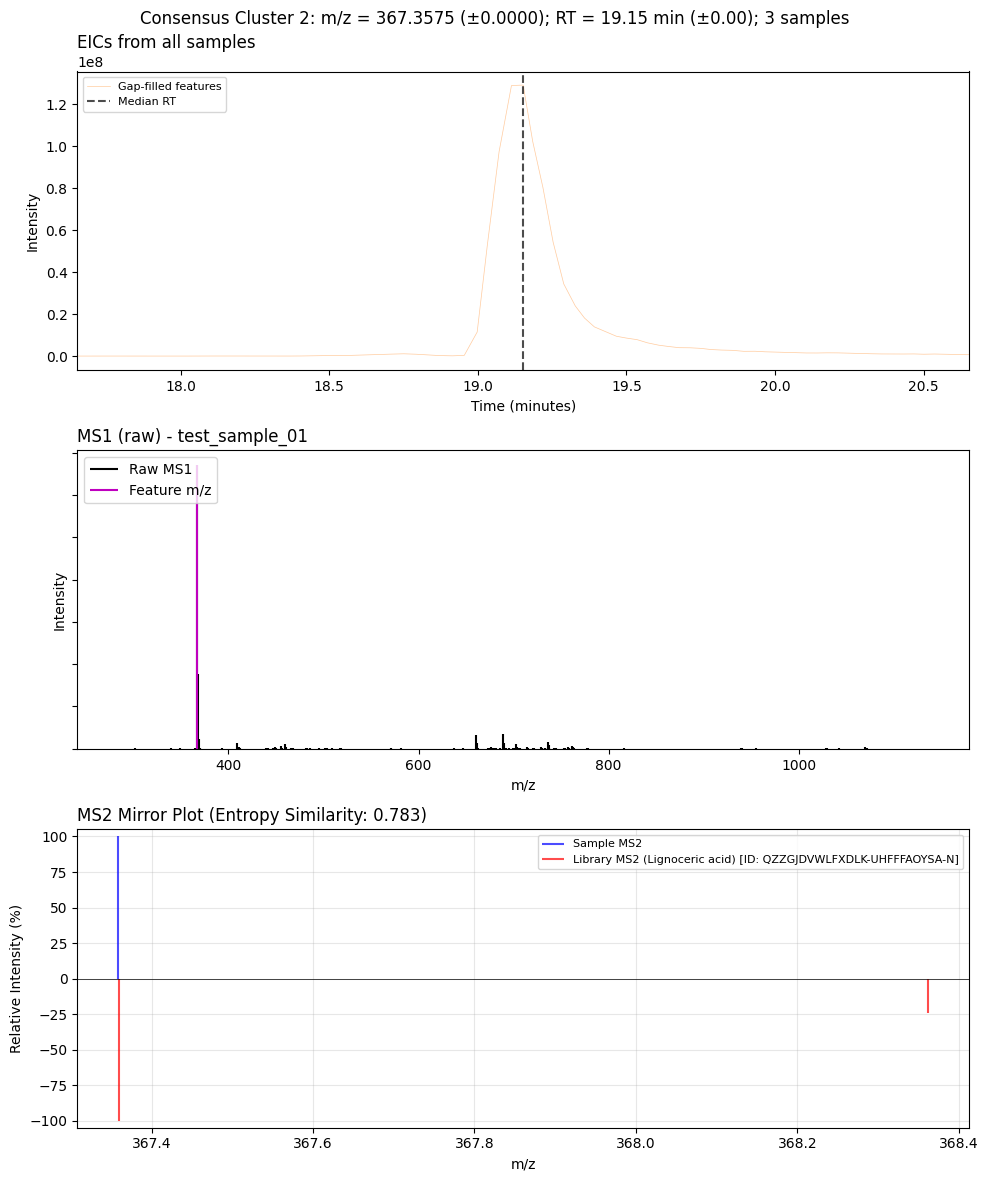

In [26]:
# View an example consensus mass feature with MS2 mirror plot
# Note that for this example, the EICs overlap because the samples are replicates.
lcms_collection.plot_cluster(
    cluster_id=2, 
    to_plot=["EIC", "MS1", "MS2_mirror"], # Default is MS2 without a mirror
    molecular_metadata=molecular_metadata,
    spectral_library=spectral_library
      # Needs the molecular_metadata object generated alongside the ms2 database above to plot the library match
)

## Step 9: Export Collection Results

Export the collection to HDF5 for later reloading, and save tables to CSV.

In [27]:
# Ensure output directory exists
processed_folder.mkdir(parents=True, exist_ok=True)

# Export collection to HDF5
collection_save_path = processed_folder / "collection_export"
exporter = LCMSCollectionExport(
    out_file_path=str(collection_save_path),
    mass_spectra_collection=lcms_collection
)
exporter.export_to_hdf5(overwrite=True, save_parameters=True)

print(f"✓ Collection exported to {collection_save_path}.hdf5")

✓ Collection exported to tutorial_collection_data/collection_export.hdf5


## Summary

This tutorial demonstrated:

1. ✓ **Sample Preparation**: Processing and exporting individual LC-MS samples to HDF5
2. ✓ **Collection Loading**: Loading multiple samples as a collection with metadata
3. ✓ **RT Alignment**: Aligning retention times across samples
4. ✓ **Consensus Features**: Clustering features across samples to identify common entities
5. ✓ **Gap Filling**: Searching for missing features in raw data
6. ✓ **Pivot Tables**: Creating sample × feature matrices for comparison
7. ✓ **Cluster Representatives**: Identifying best representative features
8. ✓ **Molecular Annotations**: Adding MS1 formula search and MS2 spectral matching
9. ✓ **Export**: Saving collection data

### Key Takeaways

- **Collections enable cross-sample analysis** - Identify features present across multiple samples and detect missing features
- **Gap filling improves coverage** - Recover features that were missed during initial peak picking
- **Consensus features reduce redundancy** - Group equivalent features across samples
- **Representative features simplify analysis** - Work with one feature per cluster instead of all variants
- **Integrated pipeline is efficient** - `process_consensus_features()` combines multiple operations in one pass and can leverage multicore processing

## Cleanup

Remove tutorial data files.

In [28]:
# Clean up tutorial data
if processed_folder.exists():
    shutil.rmtree(processed_folder)
    print(f"✓ Cleaned up tutorial data from {processed_folder}")

✓ Cleaned up tutorial data from tutorial_collection_data
